c:\Users\Juanan\anaconda3\envs\my_quant_lab\Lib\site-packages\vectorbt\data\base.py:527: UserWarning:

Symbols have mismatching index. Setting missing data points to NaN.



=== VIX-Targeting Backtest ===
Source: Yahoo via vectorbt | Symbol: ES=F
VIX source: Yahoo via vectorbt | Symbol: ^VIX
Requested analysis window: 2000-01-01 -> 2026-02-26
Warmup start used: 1998-12-31 | Warmup bars target: 262
Rows used for full calc: 6423 | Rows used for final aligned analysis: 5758
First valid input date: 2001-09-24
First invested strategy date: 2003-05-05
Final aligned analysis window: 2003-05-05 -> 2026-02-25
Target vol up/down: 0.2 / 0.1
VIX floor: 0.01 | VIX smoothing: None
Trend filter: True | EMA_PERIODS=[252] | Rising rule: EMA[t-1] > EMA[t-2]
Rolling alpha/beta window: 252 days
PointValue: 50.0 | MinLot=1.0, Step=1.0, MaxLot=1e+20
Commission: $4.0/lot/side | Spread: 0.0 pts | Slippage: 0.0 pts
Total costs deducted (final aligned window): 18840.00

Regime share (final aligned window): {'trend_up': 0.8223341437999305, 'trend_down': 0.17766585620006947}

Strategy stats:
{'total_return': 4.725149280207444, 'cagr': 0.0793702642384897, 'ann_vol': 0.1407702904057212

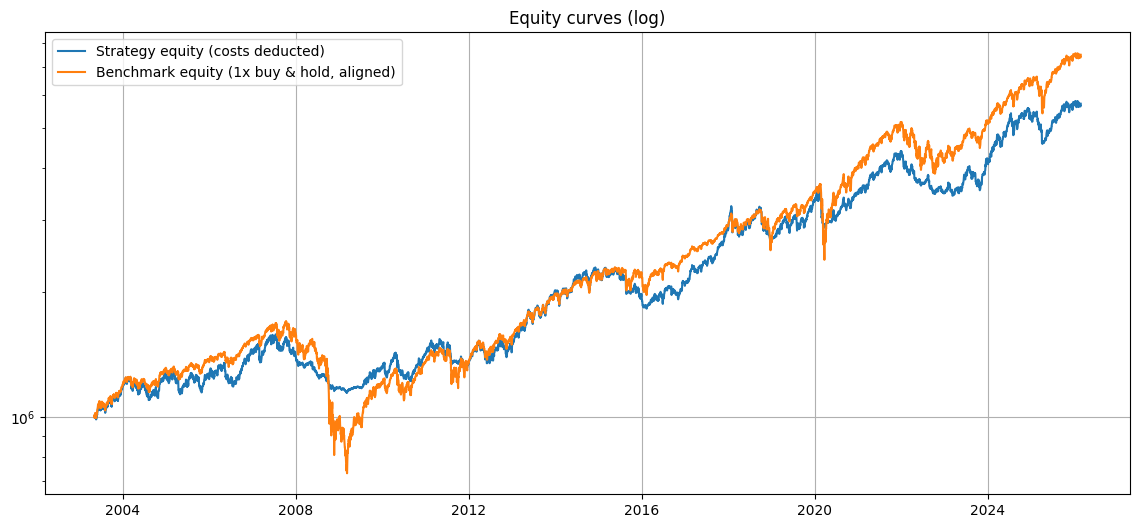

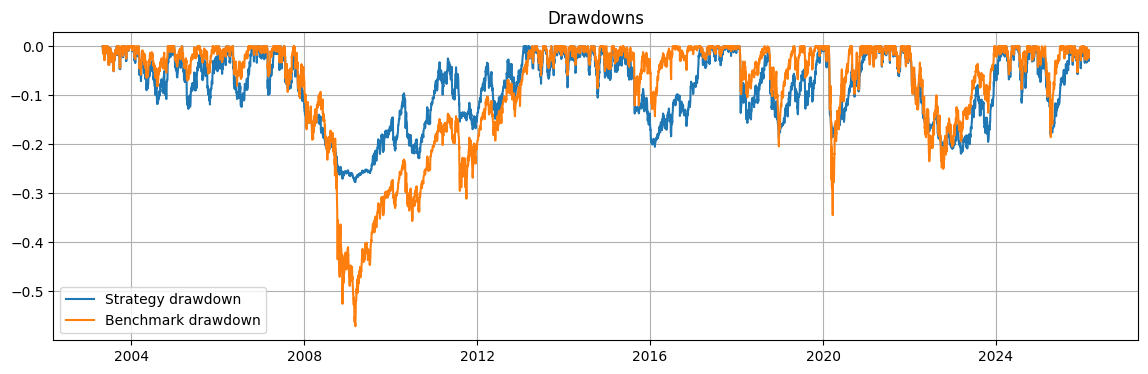

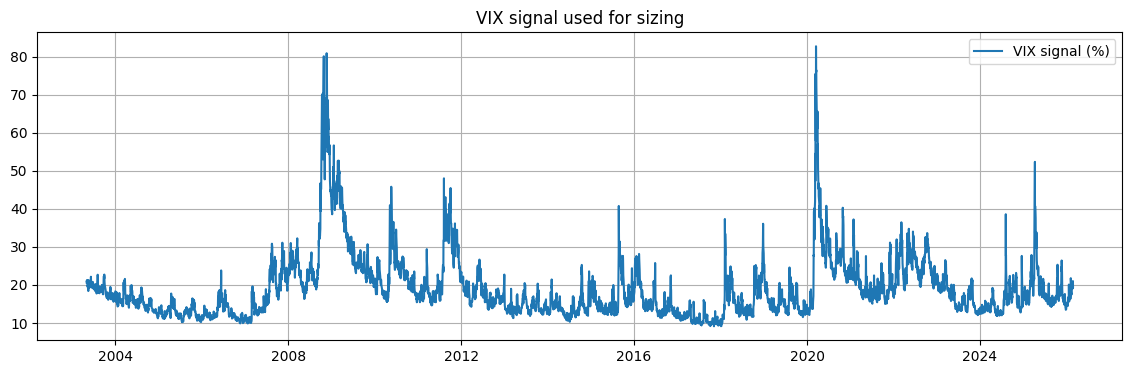

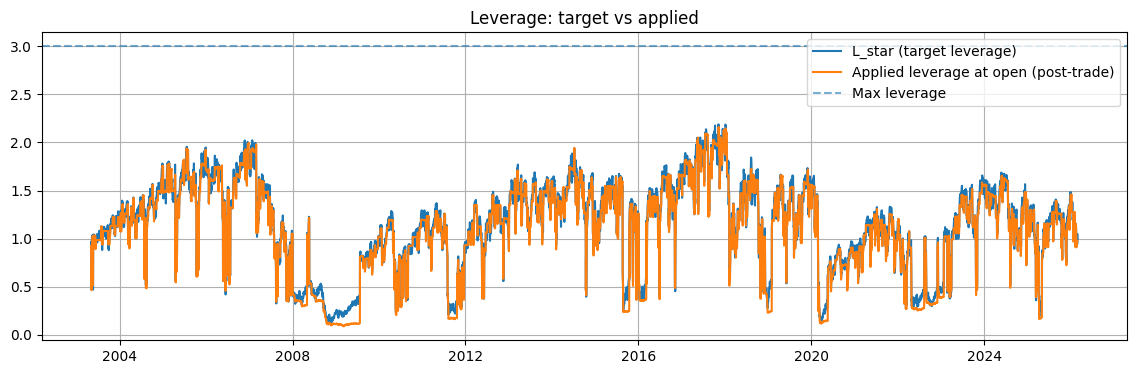

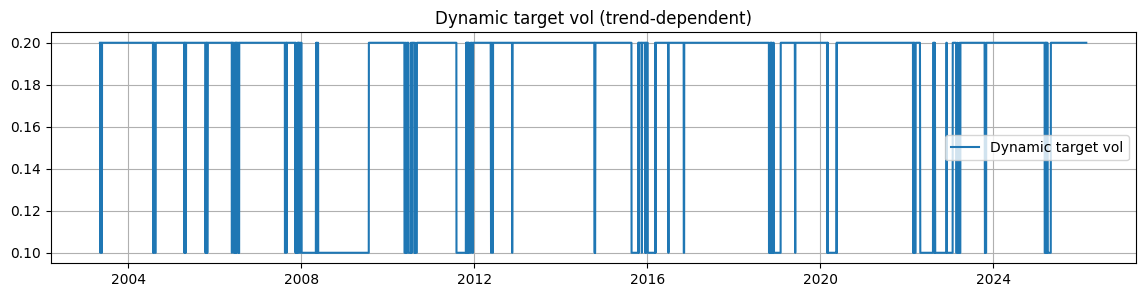

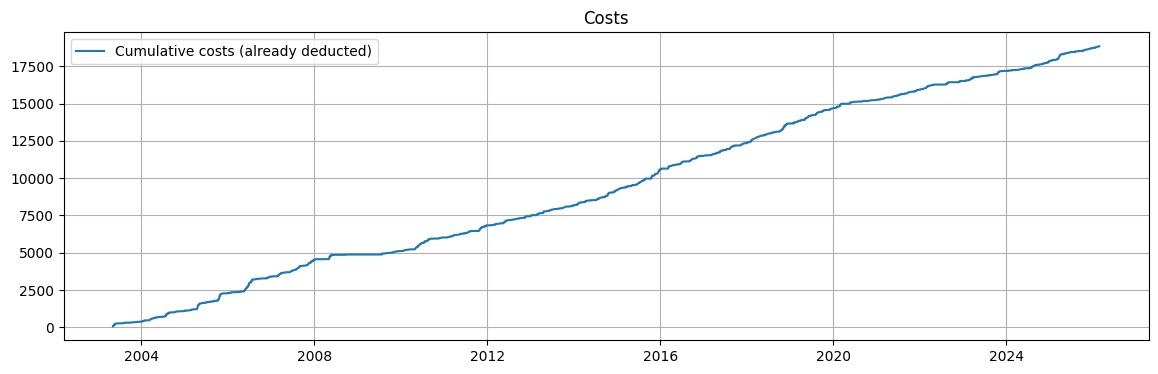

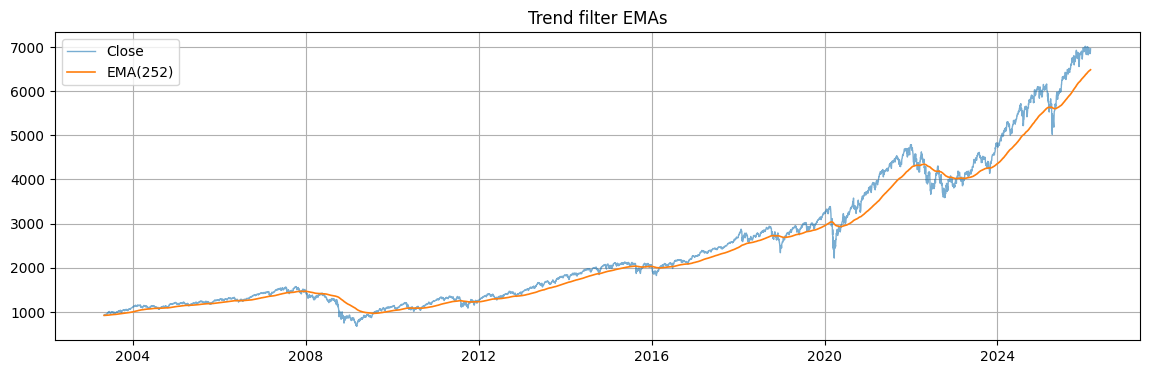

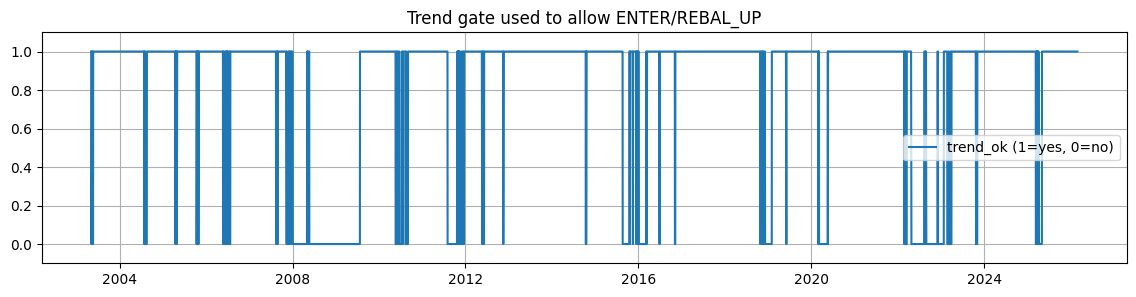

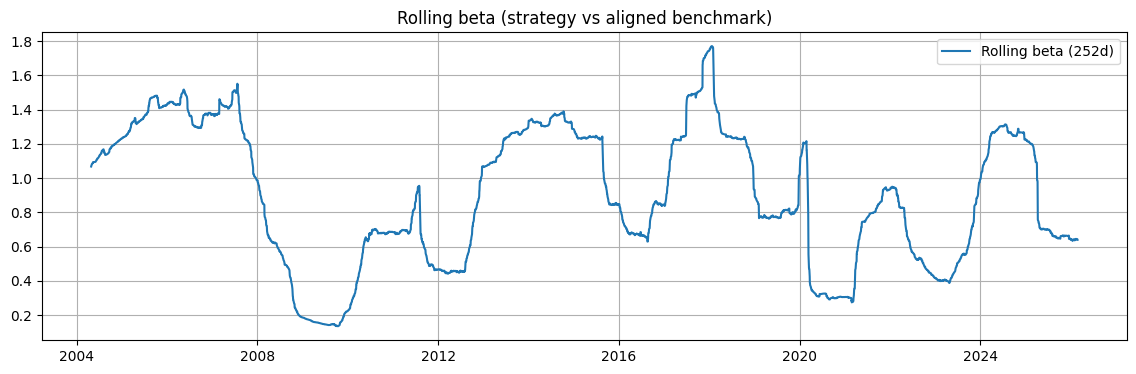

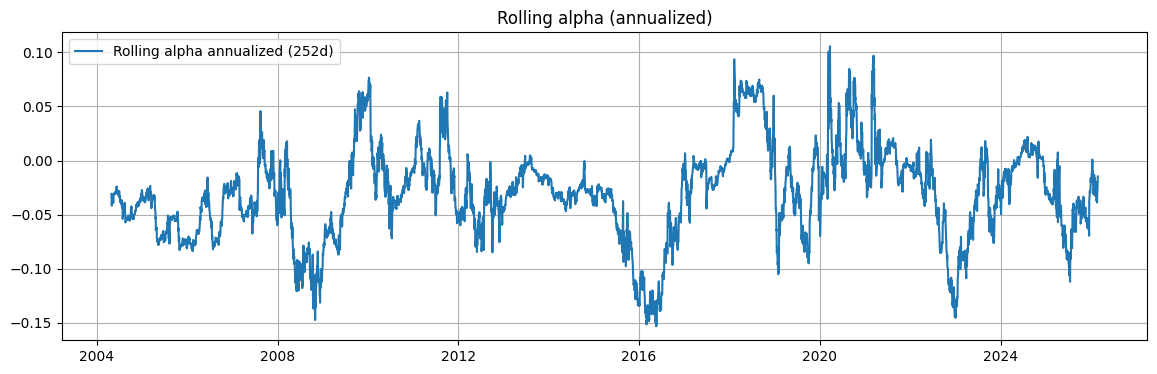


Last 25 trade events:
               date     action  open_mid  TargetVol_dyn   L_star  lots_before  lots_target  lots_after  deltaLots  chunks  commission  spread_cost  slippage_cost  order_fees  cost_total  L_cur_before   vix1  trend_ok  ema_252_t1
2025-10-21 04:00:00   REBAL_UP   6779.50            0.2 0.962464         13.0         16.0        16.0        3.0       3        12.0          0.0            0.0         0.0        12.0      0.780016 0.2078      True 6086.257228
2025-10-22 04:00:00   REBAL_UP   6776.00            0.2 1.097093         16.0         18.0        18.0        2.0       2         8.0          0.0            0.0         0.0         8.0      0.960001 0.1823      True 6091.688001
2025-10-28 04:00:00   REBAL_UP   6914.00            0.2 1.221747         18.0         20.0        20.0        2.0       2         8.0          0.0            0.0         0.0         8.0      1.078281 0.1637      True 6114.207696
2025-11-06 05:00:00 REBAL_DOWN   6828.50            0.2 1.052

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vectorbt as vbt

# =========================================================
# VIX-Targeting Backtest
# =========================================================

# ================== Data source switch ==================
USE_YF = True  # set False to load ES from MT5 CSV/TSV, VIX still from Yahoo

# ----- Requested analysis window -----
symbol = "ES=F"
vix_symbol = "^VIX"
start = "2000-01-01"
end   = "2026-02-26"

# ----- MT5 export (if USE_YF=False for ES price data) -----
csv_path = r"C:\Users\Juanan\Downloads\ES_H_Daily_201001010000_202602260000.csv"
mt5_sep = "\t"

# ================== Inputs ==================
TARGET_VOL_TREND_UP   = 0.20
TARGET_VOL_TREND_DOWN = 0.10

# --- VIX signal settings ---
# Yahoo ^VIX is quoted like 20.0 = 20% annualized vol
VIX_FLOOR = 0.01
VIX_USE_EMA = False
VIX_EMA_SPAN = 5

MaxLeverage   = 3.0
MinLeverage   = 0.0
RebalanceUp   = 0.10
RebalanceDown = 0.10
FlatEps       = 0.0

# ================== Trend filter ==================
USE_TREND_FILTER = True
EMA_PERIODS = [252]
TREND_LOOKBACK = 1
BLOCK_SCALE_UP_WHEN_TREND_BAD = True

# ================== Rolling alpha/beta ==================
ROLLING_AB_WINDOW = 252
TRADING_DAYS = 252
MAR_EQ_RET = 0.0

# ================== Contract specs ==================
TickSize   = 0.25
TickValue  = 12.5
PointValue = TickValue / TickSize  # 50 USD per 1.00 point

# ================== Volume constraints ==================
MinLot   = 1.0
LotStep  = 1.0
MaxLot   = 99999999999999999999.0

# Chunking
LotsPerChunk = 1.0  # set 0 to disable

# ================== Costs ==================
commission_per_lot_per_side = 4.0
slippage_points             = 0.0
spread_points               = 0.0
per_order_fee               = 0.0

init_cash = 1_000_000.0

# ================== Helpers ==================
def clamp(x: float, lo: float, hi: float) -> float:
    return float(min(max(x, lo), hi))

def is_weekend(ts: pd.Timestamp) -> bool:
    return ts.weekday() >= 5

def make_index_tz_naive(df: pd.DataFrame) -> pd.DataFrame:
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    if getattr(df.index, "tz", None) is not None:
        df.index = df.index.tz_convert(None)
    return df

def drawdown_from_equity(eq: pd.Series) -> pd.Series:
    peak = eq.cummax()
    return eq / peak - 1.0

def neg_annualized_vol_from_returns(rets: pd.Series, mar: float = 0.0, freq: int = 252) -> float:
    rets = rets.dropna()
    if len(rets) == 0:
        return float("nan")
    d = np.minimum(rets.to_numpy(dtype=float) - float(mar), 0.0)
    return float(np.sqrt(np.mean(d * d)) * np.sqrt(freq))

def perf_stats_from_equity(eq: pd.Series, freq: int = 252, mar_eq_ret: float = 0.0) -> dict:
    eq = eq.dropna()
    if len(eq) < 2:
        return {
            "total_return": np.nan,
            "cagr": np.nan,
            "ann_vol": np.nan,
            "neg_ann_vol": np.nan,
            "sharpe": np.nan,
            "max_dd": np.nan
        }

    rets = eq.pct_change().dropna()
    total_return = float(eq.iloc[-1] / eq.iloc[0] - 1.0)
    years = (len(eq) - 1) / freq
    cagr = float((eq.iloc[-1] / eq.iloc[0]) ** (1 / years) - 1.0) if years > 0 else np.nan

    ann_vol = float(rets.std(ddof=0) * np.sqrt(freq)) if len(rets) > 1 else np.nan
    neg_ann_vol = neg_annualized_vol_from_returns(rets, mar=mar_eq_ret, freq=freq)
    sharpe = float((rets.mean() * freq) / ann_vol) if ann_vol and ann_vol != 0 else np.nan
    max_dd = float(drawdown_from_equity(eq).min())

    return {
        "total_return": total_return,
        "cagr": cagr,
        "ann_vol": ann_vol,
        "neg_ann_vol": neg_ann_vol,
        "sharpe": sharpe,
        "max_dd": max_dd
    }

def profit_metrics_from_equity(eq: pd.Series, init_cash: float) -> dict:
    eq = eq.dropna()
    if len(eq) == 0:
        return {
            "total_net_profit": np.nan,
            "gross_profit": np.nan,
            "gross_loss": np.nan
        }

    pnl = eq.diff().dropna()
    gross_profit = float(pnl[pnl > 0].sum())
    gross_loss = float(-pnl[pnl < 0].sum())
    total_net_profit = float(eq.iloc[-1] - init_cash)

    return {
        "total_net_profit": total_net_profit,
        "gross_profit": gross_profit,
        "gross_loss": gross_loss
    }

def normalize_lots_scalar(lots: float) -> float:
    lots = min(max(lots, 0.0), MaxLot)
    lots = np.floor(lots / LotStep) * LotStep
    if lots < MinLot:
        return 0.0
    return float(lots)

def lots_for_notional_scalar(notional: float, price_mid: float, point_value: float) -> float:
    if notional <= 0.0 or price_mid <= 0.0 or point_value <= 0.0:
        return 0.0
    return normalize_lots_scalar(notional / (price_mid * point_value))

def chunk_plan(delta_lots: float, lots_per_chunk: float) -> list:
    delta_lots = float(delta_lots)
    if abs(delta_lots) < 1e-12:
        return []
    if lots_per_chunk is None or lots_per_chunk <= 0:
        return [delta_lots]

    sign = 1.0 if delta_lots > 0 else -1.0
    remaining = abs(delta_lots)

    chunks = []
    step = max(LotStep, 1e-12)
    chunk_size = max(lots_per_chunk, step)

    while remaining >= step - 1e-12:
        this = min(chunk_size, remaining)
        this = np.floor(this / step) * step
        if this < step - 1e-12:
            break
        chunks.append(sign * float(this))
        remaining -= float(this)

    return chunks

def ema(series: pd.Series, span: int) -> pd.Series:
    return series.ewm(span=int(span), adjust=False, min_periods=int(span)).mean()

def rolling_alpha_beta(strat_ret: pd.Series, bench_ret: pd.Series, window: int = 252, ann_factor: int = 252):
    df_ab = pd.concat([strat_ret.rename("S"), bench_ret.rename("B")], axis=1).dropna()
    if df_ab.empty:
        return (pd.Series(dtype=float), pd.Series(dtype=float), pd.Series(dtype=float))

    S = df_ab["S"]
    B = df_ab["B"]

    meanS = S.rolling(window).mean()
    meanB = B.rolling(window).mean()
    covSB = S.rolling(window).cov(B)
    varB  = B.rolling(window).var()

    beta = covSB / varB
    alpha_daily = meanS - beta * meanB
    alpha_ann = alpha_daily * ann_factor

    return alpha_daily.reindex(strat_ret.index), beta.reindex(strat_ret.index), alpha_ann.reindex(strat_ret.index)

# ================== Warmup planning ==================
requested_start_ts = pd.to_datetime(start)
requested_end_ts   = pd.to_datetime(end)

max_ema = int(np.max(EMA_PERIODS)) if len(EMA_PERIODS) > 0 else 0
max_warmup = max(max_ema, ROLLING_AB_WINDOW, (VIX_EMA_SPAN if VIX_USE_EMA else 1))
warmup_buffer_days = max_warmup + 10
warmup_start_ts = requested_start_ts - pd.offsets.BDay(warmup_buffer_days)

# ================== Load data ==================
if USE_YF:
    data = vbt.YFData.download(
        [symbol, vix_symbol],
        start=warmup_start_ts.strftime("%Y-%m-%d"),
        end=end
    )

    open_all = data.get("Open")
    close_all = data.get("Close")

    if isinstance(open_all, pd.Series):
        raise ValueError("Expected multi-symbol Yahoo download, but got Series for Open.")
    if isinstance(close_all, pd.Series):
        raise ValueError("Expected multi-symbol Yahoo download, but got Series for Close.")

    open_all.index = pd.to_datetime(open_all.index)
    close_all.index = pd.to_datetime(close_all.index)

    if getattr(open_all.index, "tz", None) is not None:
        open_all.index = open_all.index.tz_convert(None)
    if getattr(close_all.index, "tz", None) is not None:
        close_all.index = close_all.index.tz_convert(None)

    open_all = open_all.sort_index()
    close_all = close_all.sort_index()

    if symbol not in open_all.columns or symbol not in close_all.columns:
        raise ValueError(f"{symbol} missing from Yahoo download columns.")
    if vix_symbol not in close_all.columns:
        raise ValueError(f"{vix_symbol} missing from Yahoo download columns.")

    df = pd.DataFrame({
        "Open": open_all[symbol].astype(float),
        "Close": close_all[symbol].astype(float),
        "VIX": close_all[vix_symbol].astype(float)
    }).sort_index()

else:
    raw = pd.read_csv(csv_path, sep=mt5_sep)
    raw["date"] = pd.to_datetime(raw["<DATE>"], format="%Y.%m.%d")
    raw = raw.set_index("date").sort_index()
    df = raw.rename(columns={"<OPEN>": "Open", "<CLOSE>": "Close"})[["Open", "Close"]].astype(float)
    df = make_index_tz_naive(df)

    vix_data = vbt.YFData.download(
        vix_symbol,
        start=warmup_start_ts.strftime("%Y-%m-%d"),
        end=end
    )
    vix_close = vix_data.get("Close")

    if isinstance(vix_close, pd.DataFrame):
        if vix_symbol in vix_close.columns:
            vix_close = vix_close[vix_symbol]
        else:
            vix_close = vix_close.iloc[:, 0]

    vix_close = pd.Series(vix_close).astype(float)
    vix_close.index = pd.to_datetime(vix_close.index)
    if getattr(vix_close.index, "tz", None) is not None:
        vix_close.index = vix_close.index.tz_convert(None)
    vix_close = vix_close.sort_index()

    df = df.join(vix_close.rename("VIX"), how="left")

df = df.loc[warmup_start_ts:requested_end_ts].copy()
df = df.loc[~df.index.map(is_weekend)].copy()
df["VIX"] = df["VIX"].ffill()
df = df.dropna(subset=["Open", "Close"])

open_s  = df["Open"].astype(float)
close_s = df["Close"].astype(float)
vix_s_raw = df["VIX"].astype(float)
dates = df.index
n = len(df)

if n < max_warmup + 3:
    raise ValueError(
        f"Not enough data after filtering for warmup. Need at least {max_warmup + 3} rows, got {n}. "
        f"Try loading earlier history before {requested_start_ts.date()}."
    )

if vix_s_raw.dropna().empty:
    raise ValueError("VIX series is entirely NaN after download/alignment.")

# ================== VIX signal ==================
vix_signal = (vix_s_raw / 100.0).clip(lower=VIX_FLOOR)
if VIX_USE_EMA:
    vix_signal = ema(vix_signal, VIX_EMA_SPAN)
vix1 = vix_signal.shift(1)

# ================== Trend filter series ==================
ema_map = {p: ema(close_s, p) for p in EMA_PERIODS}
ema_map_1 = {p: ema_map[p].shift(1) for p in EMA_PERIODS}

ema_rising_flags = []
for p in EMA_PERIODS:
    ema_rising_flags.append(ema_map_1[p] > ema_map_1[p].shift(int(TREND_LOOKBACK)))

trend_ok = ema_rising_flags[0] if len(ema_rising_flags) > 0 else pd.Series(True, index=dates)
for flag in ema_rising_flags[1:]:
    trend_ok = trend_ok & flag
trend_ok = trend_ok.fillna(False)

# ================== Dynamic target vol ==================
TargetVol_dyn = pd.Series(
    np.where(trend_ok.values, TARGET_VOL_TREND_UP, TARGET_VOL_TREND_DOWN),
    index=dates
).astype(float)

L_star = (TargetVol_dyn / vix1).replace([np.inf, -np.inf], np.nan).fillna(0.0)
L_star = L_star.apply(lambda x: clamp(x, MinLeverage, MaxLeverage))
if FlatEps > 0:
    L_star = L_star.where(L_star >= FlatEps, 0.0)

# ================== Strict input-valid mask ==================
live_input_mask = pd.Series(True, index=dates)
live_input_mask &= vix1.notna()
live_input_mask &= TargetVol_dyn.notna()
live_input_mask &= L_star.notna()

for p in EMA_PERIODS:
    live_input_mask &= ema_map_1[p].notna()
    if USE_TREND_FILTER:
        live_input_mask &= ema_map_1[p].shift(int(TREND_LOOKBACK)).notna()

# ================== Simulation ==================
equity = pd.Series(np.nan, index=dates)
costs  = pd.Series(0.0, index=dates)
lots_after = pd.Series(0.0, index=dates)
applied_L = pd.Series(0.0, index=dates)
L_cur_open_before = pd.Series(np.nan, index=dates)
L_cur_open_after  = pd.Series(np.nan, index=dates)
trend_ok_used = pd.Series(False, index=dates)

trades = []

eq = float(init_cash)
curLots = 0.0
prev_close = float(close_s.iloc[0])

EPS_LOTS = 1e-12

half_spread = float(spread_points) / 2.0
half_spread_cost_per_lot = half_spread * PointValue
slip_cost_per_lot = float(slippage_points) * PointValue

for i in range(n):
    dt = dates[i]
    o_mid = float(open_s.iat[i])
    c_mid = float(close_s.iat[i])

    if not bool(live_input_mask.iat[i]):
        equity.iat[i] = np.nan
        lots_after.iat[i] = curLots
        prev_close = c_mid
        continue

    eq += curLots * (o_mid - prev_close) * PointValue

    Ls = float(L_star.iat[i])

    notional_cur_open = curLots * o_mid * PointValue
    L_cur_before = (notional_cur_open / eq) if eq > 0 else 0.0
    L_cur_open_before.iat[i] = L_cur_before

    lots_target = lots_for_notional_scalar(Ls * eq, o_mid, PointValue) if Ls > 0 else 0.0
    lots_target = normalize_lots_scalar(lots_target)

    allow_up = True
    if USE_TREND_FILTER:
        allow_up = bool(trend_ok.iat[i])
    trend_ok_used.iat[i] = allow_up

    doTrade = False
    increasing_exposure = False

    if curLots <= 0.0 + EPS_LOTS:
        increasing_exposure = (lots_target > 0.0 + EPS_LOTS)
        if increasing_exposure:
            doTrade = True
    else:
        if lots_target <= 0.0 + EPS_LOTS:
            increasing_exposure = False
            doTrade = True
        else:
            rel_change = (abs(Ls - L_cur_before) / L_cur_before) if L_cur_before > 1e-9 else abs(Ls - L_cur_before)
            if Ls > L_cur_before:
                increasing_exposure = True
                doTrade = (rel_change > RebalanceUp)
            else:
                increasing_exposure = False
                doTrade = (rel_change > RebalanceDown)

    if BLOCK_SCALE_UP_WHEN_TREND_BAD and doTrade and increasing_exposure and not allow_up:
        doTrade = False

    lots_before = curLots

    if doTrade:
        deltaLots = lots_target - curLots
        chunks = chunk_plan(deltaLots, LotsPerChunk)

        total_commission  = 0.0
        total_spread_cost = 0.0
        total_slip_cost   = 0.0
        total_order_fees  = 0.0

        for ch in chunks:
            ch_abs = abs(ch)
            if ch_abs < EPS_LOTS:
                continue

            total_commission  += ch_abs * commission_per_lot_per_side
            total_spread_cost += ch_abs * half_spread_cost_per_lot
            total_slip_cost   += ch_abs * slip_cost_per_lot
            total_order_fees  += per_order_fee

            curLots += ch
            curLots = normalize_lots_scalar(curLots)

        total_cost = total_commission + total_spread_cost + total_slip_cost + total_order_fees
        if total_cost != 0.0:
            eq -= total_cost
            costs.iat[i] += total_cost

        if abs(lots_target - lots_before) >= EPS_LOTS and len(chunks) > 0:
            if lots_before <= 0.0 + EPS_LOTS and curLots > 0.0:
                action = "ENTER"
            elif lots_before > 0.0 + EPS_LOTS and curLots <= 0.0 + EPS_LOTS:
                action = "FLAT"
            elif curLots > lots_before:
                action = "REBAL_UP"
            else:
                action = "REBAL_DOWN"

            row = {
                "date": dt,
                "action": action,
                "open_mid": o_mid,
                "close_mid": c_mid,
                "vix1": float(vix1.iat[i]),
                "TargetVol_dyn": float(TargetVol_dyn.iat[i]),
                "L_star": Ls,
                "lots_before": lots_before,
                "lots_target": lots_target,
                "lots_after": curLots,
                "deltaLots": (lots_target - lots_before),
                "chunks": len(chunks),
                "commission": total_commission,
                "spread_cost": total_spread_cost,
                "slippage_cost": total_slip_cost,
                "order_fees": total_order_fees,
                "cost_total": total_cost,
                "equity_after_cost": eq,
                "L_cur_before": L_cur_before,
                "trend_ok": allow_up,
            }
            for p in EMA_PERIODS:
                row[f"ema_{p}_t1"] = float(ema_map_1[p].iat[i]) if not np.isnan(ema_map_1[p].iat[i]) else np.nan
            trades.append(row)

    notional_after_open = curLots * o_mid * PointValue
    L_cur_after = (notional_after_open / eq) if eq > 0 else 0.0
    L_cur_open_after.iat[i] = L_cur_after
    applied_L.iat[i] = L_cur_after

    eq += curLots * (c_mid - o_mid) * PointValue

    equity.iat[i] = eq
    lots_after.iat[i] = curLots
    prev_close = c_mid

trades_df = pd.DataFrame(trades).sort_values("date").reset_index(drop=True) if trades else pd.DataFrame()

# ================== Analysis window ==================
requested_mask = dates >= requested_start_ts
base_mask = requested_mask & live_input_mask

equity_base = equity.loc[base_mask].dropna()
lots_base = lots_after.loc[base_mask]

if len(equity_base) < 2:
    raise ValueError(
        f"No valid post-warmup analysis data available inside requested window "
        f"{requested_start_ts.date()} -> {requested_end_ts.date()}."
    )

# IMPORTANT:
# Trim from first date where strategy actually has exposure.
invested_idx = lots_base[lots_base > 0].index

if len(invested_idx) == 0:
    raise ValueError("Strategy never gets invested in the requested analysis window.")

strategy_start_ts = invested_idx.min()
analysis_idx = equity_base.loc[equity_base.index >= strategy_start_ts].index

equity_analysis = equity.loc[analysis_idx]
costs_analysis = costs.loc[analysis_idx]
applied_L_analysis = applied_L.loc[analysis_idx]
L_star_analysis = L_star.loc[analysis_idx]
TargetVol_dyn_analysis = TargetVol_dyn.loc[analysis_idx]
trend_ok_used_analysis = trend_ok_used.loc[analysis_idx]
close_analysis = close_s.loc[analysis_idx]
vix_analysis = vix_signal.loc[analysis_idx]
lots_analysis = lots_after.loc[analysis_idx]

# Benchmark starts on exact same first-invested date
bench_equity = init_cash * (close_analysis / float(close_analysis.iloc[0]))

if not trades_df.empty:
    trades_df = trades_df.loc[trades_df["date"] >= strategy_start_ts].reset_index(drop=True)

profit_metrics = profit_metrics_from_equity(equity_analysis, init_cash=init_cash)

# ================== Rolling alpha/beta ==================
strat_rets = equity_analysis.pct_change().dropna()
bench_rets = bench_equity.pct_change().dropna()

ab_idx = strat_rets.index.intersection(bench_rets.index)
strat_rets_al = strat_rets.loc[ab_idx]
bench_rets_al = bench_rets.loc[ab_idx]

alpha_daily, beta, alpha_ann = rolling_alpha_beta(
    strat_ret=strat_rets_al,
    bench_ret=bench_rets_al,
    window=ROLLING_AB_WINDOW,
    ann_factor=TRADING_DAYS
)

# ================== Output ==================
print("=== VIX-Targeting Backtest ===")
print(f"Source: {'Yahoo via vectorbt' if USE_YF else 'MT5 export + Yahoo VIX'} | Symbol: {symbol if USE_YF else 'MT5_FILE'}")
print(f"VIX source: Yahoo via vectorbt | Symbol: {vix_symbol}")
print(f"Requested analysis window: {requested_start_ts.date()} -> {requested_end_ts.date()}")
print(f"Warmup start used: {warmup_start_ts.date()} | Warmup bars target: {warmup_buffer_days}")
print(f"Rows used for full calc: {len(df)} | Rows used for final aligned analysis: {len(analysis_idx)}")
print(f"First valid input date: {equity_base.index.min().date()}")
print(f"First invested strategy date: {strategy_start_ts.date()}")
print(f"Final aligned analysis window: {analysis_idx.min().date()} -> {analysis_idx.max().date()}")
print(f"Target vol up/down: {TARGET_VOL_TREND_UP} / {TARGET_VOL_TREND_DOWN}")
print(f"VIX floor: {VIX_FLOOR} | VIX smoothing: {'EMA(' + str(VIX_EMA_SPAN) + ')' if VIX_USE_EMA else 'None'}")
print(f"Trend filter: {USE_TREND_FILTER} | EMA_PERIODS={EMA_PERIODS} | Rising rule: EMA[t-1] > EMA[t-2]")
print(f"Rolling alpha/beta window: {ROLLING_AB_WINDOW} days")
print(f"PointValue: {PointValue} | MinLot={MinLot}, Step={LotStep}, MaxLot={MaxLot}")
print(f"Commission: ${commission_per_lot_per_side}/lot/side | Spread: {spread_points} pts | Slippage: {slippage_points} pts")
print(f"Total costs deducted (final aligned window): {float(costs_analysis.sum()):.2f}")
print()

regime_up = float((TargetVol_dyn_analysis == TARGET_VOL_TREND_UP).mean())
regime_down = float((TargetVol_dyn_analysis == TARGET_VOL_TREND_DOWN).mean())
print("Regime share (final aligned window):", {"trend_up": regime_up, "trend_down": regime_down})
print()

print("Strategy stats:")
print(perf_stats_from_equity(equity_analysis, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

print("\nProfit metrics:")
print(profit_metrics)

print("\nBenchmark stats (1x buy&hold, aligned to first invested strategy date):")
print(perf_stats_from_equity(bench_equity, freq=TRADING_DAYS, mar_eq_ret=MAR_EQ_RET))

last_beta = beta.dropna().iloc[-1] if beta.dropna().shape[0] else np.nan
last_alpha_ann = alpha_ann.dropna().iloc[-1] if alpha_ann.dropna().shape[0] else np.nan
print("\nRolling alpha/beta (latest available):")
print({
    "beta": float(last_beta) if np.isfinite(last_beta) else np.nan,
    "alpha_ann": float(last_alpha_ann) if np.isfinite(last_alpha_ann) else np.nan
})

print("\nTrade counts:")
if trades_df.empty:
    print({"total_trade_events_logged": 0})
else:
    print({
        "enter": int((trades_df["action"] == "ENTER").sum()),
        "rebal_up": int((trades_df["action"] == "REBAL_UP").sum()),
        "rebal_down": int((trades_df["action"] == "REBAL_DOWN").sum()),
        "flat": int((trades_df["action"] == "FLAT").sum()),
        "total_trade_events_logged": int(len(trades_df))
    })

# ================== Plots ==================
plt.figure(figsize=(14, 6))
plt.plot(equity_analysis, label="Strategy equity (costs deducted)")
plt.plot(bench_equity, label="Benchmark equity (1x buy & hold, aligned)")
plt.yscale("log")
plt.title("Equity curves (log)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(drawdown_from_equity(equity_analysis), label="Strategy drawdown")
plt.plot(drawdown_from_equity(bench_equity), label="Benchmark drawdown")
plt.title("Drawdowns")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(vix_analysis * 100.0, linewidth=1.5, label="VIX signal (%)")
plt.title("VIX signal used for sizing")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(L_star_analysis, label="L_star (target leverage)")
plt.plot(applied_L_analysis, label="Applied leverage at open (post-trade)")
plt.axhline(MaxLeverage, linestyle="--", alpha=0.6, label="Max leverage")
plt.title("Leverage: target vs applied")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(TargetVol_dyn_analysis, label="Dynamic target vol")
plt.title("Dynamic target vol (trend-dependent)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(costs_analysis.cumsum(), label="Cumulative costs (already deducted)")
plt.title("Costs")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(close_analysis, linewidth=1, alpha=0.6, label="Close")
for p in EMA_PERIODS:
    plt.plot(ema_map[p].loc[analysis_idx], linewidth=1.2, label=f"EMA({p})")
plt.title("Trend filter EMAs")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(trend_ok_used_analysis.astype(int), label="trend_ok (1=yes, 0=no)")
plt.ylim(-0.1, 1.1)
plt.title("Trend gate used to allow ENTER/REBAL_UP")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(beta, label=f"Rolling beta ({ROLLING_AB_WINDOW}d)")
plt.title("Rolling beta (strategy vs aligned benchmark)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(alpha_ann, label=f"Rolling alpha annualized ({ROLLING_AB_WINDOW}d)")
plt.title("Rolling alpha (annualized)")
plt.grid(True)
plt.legend()
plt.show()

if trades_df.empty:
    print("\nNo trade events logged.")
else:
    print("\nLast 25 trade events:")
    base_cols = [
        "date", "action", "open_mid", "TargetVol_dyn", "L_star", "lots_before", "lots_target", "lots_after",
        "deltaLots", "chunks", "commission", "spread_cost", "slippage_cost", "order_fees", "cost_total",
        "L_cur_before", "vix1", "trend_ok"
    ]
    ema_cols = [f"ema_{p}_t1" for p in EMA_PERIODS]
    cols = base_cols + ema_cols
    print(trades_df[cols].tail(25).to_string(index=False))